# PIKAN prediction for the infinite-domain problem

Train a physics-informed Kolmogorov-Arnold network (PIKAN) using the best KAN configuration found during hyperparameter tuning, then compare the learned solution and coefficient with their analytical references.

## Reproducible setup

The notebook imports the shared infinite-domain problem definition and PINN/KAN training utilities.

In [18]:
from pathlib import Path
import sys
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import torch

# Find the repository utilities directory from either the notebook folder or workspace root.
notebook_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir()),
    notebook_dir,
)
utilities_dir = repo_root / "utils"
if str(utilities_dir) not in sys.path:
    sys.path.insert(0, str(utilities_dir))

import infinite
import pinns_infinite
reload(infinite)
reload(pinns_infinite)

from infinite import analytical_solution_inf, coefficient_inf, evaluate_model_inf
from pinns_infinite import build_models_KAN, set_seed, train_dual_network

set_seed(42)
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Tuned PIKAN configuration

These values come from the best recorded infinite-domain KAN study: three hidden layers, 25 units per layer, grid size 5, spline order 4, and learning rate $10^{-2}$. 

In [19]:
config = {
    "hidden_layers": 3,
    "hidden_units": 25,
    "grid_size": 5,
    "spline_order": 4,
    "adam_lr": 1e-2,
    "adam_iters": 2000,
    "lbfgs_iters": 2000,
    "sampling": "gaussian",
    "sigma": 5.5,
    "exp_scale": 1.0,
    "n_obs_u": 100,
    "n_obs_k": 100,
    "n_pde": 1000,
    "seed": 2,
    "pde_alpha": 0.5,
    "pde_beta": 5.0,
    "epsilon": 1.0,
}

for name, value in config.items():
    print(f"{name}: {value}")

hidden_layers: 3
hidden_units: 25
grid_size: 5
spline_order: 4
adam_lr: 0.01
adam_iters: 2000
lbfgs_iters: 2000
sampling: gaussian
sigma: 5.5
exp_scale: 1.0
n_obs_u: 100
n_obs_k: 100
n_pde: 1000
seed: 2
pde_alpha: 0.5
pde_beta: 5.0
epsilon: 1.0


## Build the KAN models

The two KANs learn the solution $u(x,y)$ and variable coefficient $k(x,y)$ jointly through the physics-informed loss.

In [12]:
model_u, model_k = build_models_KAN(
    device=device,
    hidden_layers=config["hidden_layers"],
    hidden_units=config["hidden_units"],
    grid_size=config["grid_size"],
    spline_order=config["spline_order"],
)

print(model_u)
print(model_k)

KAN(
  (layers): ModuleList(
    (0-3): 4 x KANLinear(
      (base_activation): SiLU()
    )
  )
)
KAN(
  (layers): ModuleList(
    (0-3): 4 x KANLinear(
      (base_activation): SiLU()
    )
  )
)


## Load the optimal PIKAN

This cell loads the stored models from the best infinite-domain hyperparameter run; no retraining is performed.

In [13]:
results_dir = repo_root / "main" / "03_individual_prediction" / "results"
weights_dir = repo_root / "main" / "02_hyperparameter_tunning" / "results_kan_optuna_2026-09-14_21-57-58" / "KAN" / "2026-09-14_23-59-14"
model_u_path = weights_dir / "model_u.pt"
model_k_path = weights_dir / "model_k.pt"
if not model_u_path.exists() or not model_k_path.exists():
    raise FileNotFoundError(f"Optimal model weights not found in: {weights_dir}")

model_u.load_state_dict(torch.load(model_u_path, map_location=device))
model_k.load_state_dict(torch.load(model_k_path, map_location=device))
model_u.eval()
model_k.eval()
metrics_path = weights_dir / "run_metrics_and_config.json"
if metrics_path.exists():
    import json
    with metrics_path.open() as file:
        optimal_run = json.load(file)
    metrics = {
        name: float(optimal_run[name])
        for name in (
            "err_u_global", "err_k_global",
            "err_u_inside", "err_k_inside",
            "err_u_outside", "err_k_outside",
        )
        if name in optimal_run
    }
else:
    metrics = {}
print(f"Loaded optimal KAN weights: {weights_dir}")

Loaded optimal KAN weights: /home/orincon/unbounded-domains/main/02_hyperparameter_tunning/results_kan_optuna_2026-09-14_21-57-58/KAN/2026-09-14_23-59-14


## Evaluate against the analytical solution

Compute global, in-domain, and out-of-domain mean absolute errors for both learned fields.

In [14]:
evaluation = evaluate_model_inf(
    model_u=model_u,
    model_k=model_k,
    analytical_solution=analytical_solution_inf,
    coefficient=coefficient_inf,
    sampling=config["sampling"],
    train_xmin=-5.0,
    train_xmax=5.0,
    train_ymin=-5.0,
    train_ymax=5.0,
    eval_xmin=-8.0,
    eval_xmax=8.0,
    eval_ymin=-8.0,
    eval_ymax=8.0,
    n_grid=400,
    alpha=config["pde_alpha"],
    beta=config["pde_beta"],
    epsilon=config["epsilon"],
    device=device,
    verbose=True,
)

metric_names = [
    "err_u_global", "err_k_global",
    "err_u_inside", "err_k_inside",
    "err_u_outside", "err_k_outside",
]
metrics = {name: float(evaluation[name]) for name in metric_names}
metrics


Spatial generalization (MAE)
Training domain : [-5.0, 5.0] × [-5.0, 5.0]
Evaluation domain : [-8.0, 8.0] × [-8.0, 8.0]

Global MAE
u : 1.099e-03
k : 1.072e-03

Inside training domain
u : 1.441e-03
k : 7.301e-04

Outside training domain
u : 8.795e-04
k : 1.292e-03


{'err_u_global': 0.001098704766821438,
 'err_k_global': 0.001072381301849149,
 'err_u_inside': 0.0014406407356177093,
 'err_k_inside': 0.0007301386591252567,
 'err_u_outside': 0.0008795150432340848,
 'err_k_outside': 0.0012917676112875417}

## Visual comparison

The first row shows the analytical and predicted solution $u$; the second row shows the analytical and predicted coefficient $k$. The last column reports absolute errors.

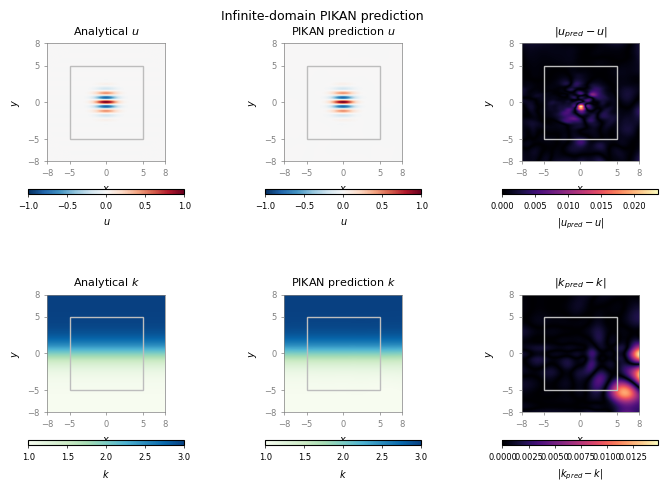

Saved weights and metadata to: /home/orincon/unbounded-domains/main/03_individual_prediction/results/pikan_infinite_tuned_weights.pt


In [15]:
X = evaluation["X"]
Y = evaluation["Y"]
U_exact = analytical_solution_inf(X, Y, config["pde_alpha"], config["pde_beta"])
K_exact = coefficient_inf(X, Y, config["epsilon"])
U_pred = evaluation["U_pred"]
K_pred = evaluation["K_pred"]

train_xmin, train_xmax, train_ymin, train_ymax = -5.0, 5.0, -5.0, 5.0
eval_xmin, eval_xmax, eval_ymin, eval_ymax = -8.0, 8.0, -8.0, 8.0
extent = [eval_xmin, eval_xmax, eval_ymin, eval_ymax]

fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.8))

panels = [
    (U_exact, "Analytical $u$", "RdBu_r", -1, 1, r"$u$"),
    (U_pred, "PIKAN prediction $u$", "RdBu_r", -1, 1, r"$u$"),
    (np.abs(U_pred - U_exact), r"$|u_{pred}-u|$", "magma", 0, None, r"$|u_{pred}-u|$"),
    (K_exact, "Analytical $k$", "GnBu", 1, 3, r"$k$"),
    (K_pred, "PIKAN prediction $k$", "GnBu", 1, 3, r"$k$"),
    (np.abs(K_pred - K_exact), r"$|k_{pred}-k|$", "magma", 0, None, r"$|k_{pred}-k|$"),
]

for axis, (values, title, cmap, vmin, vmax, colorbar_label) in zip(axes.ravel(), panels):
    image = axis.imshow(
        values,
        extent=extent,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )
    axis.add_patch(
        plt.Rectangle(
            (train_xmin, train_ymin),
            train_xmax - train_xmin,
            train_ymax - train_ymin,
            fill=False,
            edgecolor="#BDBDBD",
            linewidth=1.0,
        )
    )
    axis.set_box_aspect(1)
    axis.set_xlim(eval_xmin, eval_xmax)
    axis.set_ylim(eval_ymin, eval_ymax)
    axis.set_title(title, fontsize=8)
    axis.set_xlabel("$x$", fontsize=7)
    axis.set_ylabel("$y$", fontsize=7)
    axis.set_xticks([eval_xmin, -5, 0, 5, eval_xmax])
    axis.set_yticks([eval_ymin, -5, 0, 5, eval_ymax])
    axis.tick_params(labelsize=6, length=2, width=0.5, colors="gray")
    for spine in axis.spines.values():
        spine.set_color("gray")
        spine.set_linewidth(0.5)
    colorbar = fig.colorbar(
        image,
        ax=axis,
        orientation="horizontal",
        fraction=0.045,
        pad=0.18,
        aspect=28,
    )
    colorbar.set_label(colorbar_label, fontsize=7)
    colorbar.ax.tick_params(labelsize=6, length=2, width=0.5)

fig.suptitle("Infinite-domain PIKAN prediction", fontsize=9, y=0.99)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.08, top=0.92, wspace=0.52, hspace=0.65)
plt.show()

weights_path = results_dir / "pikan_infinite_tuned_weights.pt"
torch.save(
    {
        "model_u": model_u.state_dict(),
        "model_k": model_k.state_dict(),
        "config": config,
        "metrics": metrics,
    },
    weights_path,
)
print(f"Saved weights and metadata to: {weights_path}")